In [2]:
import pandas as pd 
import numpy as np


In [3]:
df=pd.read_csv(r"C:\Users\Suyash\Downloads\synthetic_personal_finance_dataset.csv")
print(df)

      user_id  age  gender education_level employment_status    job_title  \
0      U00001   56  Female     High School     Self-employed  Salesperson   
1      U00002   19  Female             PhD          Employed  Salesperson   
2      U00003   20  Female          Master          Employed      Teacher   
3      U00004   25    Male             PhD          Employed      Manager   
4      U00005   53  Female             PhD          Employed      Student   
...       ...  ...     ...             ...               ...          ...   
32419  U32420   30  Female     High School          Employed  Salesperson   
32420  U32421   51  Female          Master          Employed      Student   
32421  U32422   18  Female        Bachelor     Self-employed       Doctor   
32422  U32423   36   Other     High School     Self-employed   Accountant   
32423  U32424   39  Female          Master          Employed     Engineer   

       monthly_income_usd  monthly_expenses_usd  savings_usd has_loan  \
0 

In [4]:
X=df[['monthly_expenses_usd','savings_usd','loan_amount_usd','credit_score']]
y=df['monthly_income_usd']
print(y.head())
print(X.head())
print(X.info())
print(y.info())

0    3531.69
1    3531.73
2    2799.49
3    5894.88
4    5128.93
Name: monthly_income_usd, dtype: float64
   monthly_expenses_usd  savings_usd  loan_amount_usd  credit_score
0               1182.59    367655.03             0.00           430
1               2367.99    260869.10        146323.34           543
2               1003.91    230921.21             0.00           754
3               4440.12    304815.51         93242.37           461
4               4137.61    461509.48             0.00           516
<class 'pandas.DataFrame'>
RangeIndex: 32424 entries, 0 to 32423
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   monthly_expenses_usd  32424 non-null  float64
 1   savings_usd           32424 non-null  float64
 2   loan_amount_usd       32424 non-null  float64
 3   credit_score          32424 non-null  int64  
dtypes: float64(3), int64(1)
memory usage: 1013.4 KB
None
<class 'pandas.Series'>
R

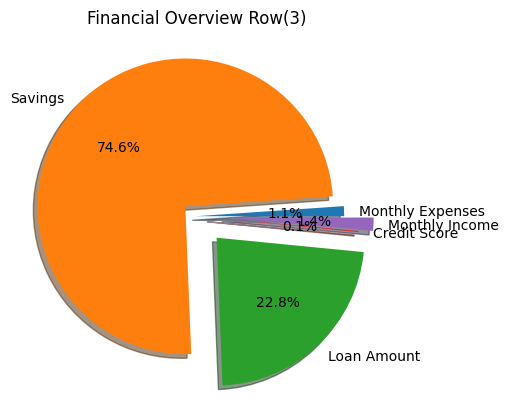

In [5]:
import matplotlib.pyplot as plt
row=X.iloc[3]
income=y.iloc[3]

labels = ['Monthly Expenses', 'Savings', 'Loan Amount', 'Credit Score', 'Monthly Income']
values = [row['monthly_expenses_usd'], row['savings_usd'], row['loan_amount_usd'], row['credit_score'], income]

plt.pie(values,labels=labels,autopct='%1.1f%%',explode=[0.0,0.1,0.2,0.1,0.2],shadow=True,)
plt.title("Financial Overview Row(3)")
plt.show()

In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.2,random_state=42)

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
from sklearn.cluster import KMeans
kmeans= KMeans(n_clusters=3,random_state=42)
clusters=kmeans.fit_predict(X_scaled)
df['Cluster']=clusters
print(df.groupby('Cluster')[[    'monthly_income_usd',
    'monthly_expenses_usd',
    'savings_usd',
    'loan_amount_usd',
    'credit_score']].mean(numeric_only=True))


         monthly_income_usd  monthly_expenses_usd    savings_usd  \
Cluster                                                            
0               3770.109329           2210.082624  206606.519364   
1               5794.576261           3785.459276  450204.401015   
2               3136.080545           1734.317023  142607.688565   

         loan_amount_usd  credit_score  
Cluster                                 
0          352971.243295    577.697124  
1           47963.016938    571.457087  
2           19389.820597    576.358830  


In [9]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=300, random_state=42,max_depth=6,min_samples_split=10,min_samples_leaf=5)
rf.fit(X_train, y_train)
predictions = rf.predict(X_test)

result = pd.DataFrame({
    'Actual': y_test.iloc[:5],
    'Predicted': predictions[:5]
})

print(result)

        Actual    Predicted
32233  4164.52  5344.263885
28076  3231.62  3243.728068
14815  4078.42  4525.057814
6676   2098.82  2547.784518
5034   2188.02  2674.958461


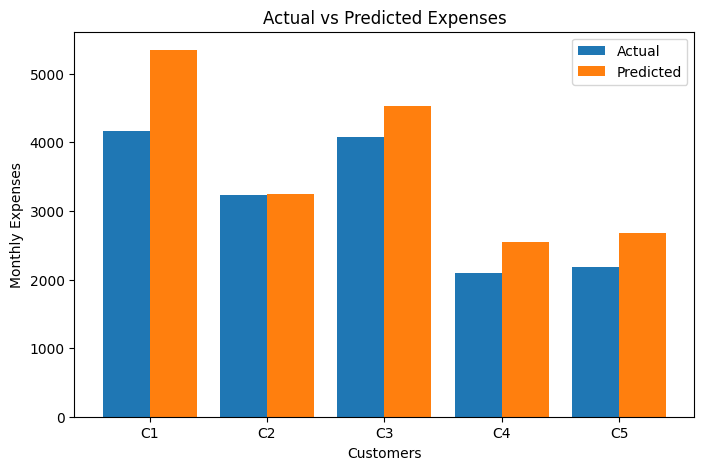

In [10]:
import numpy as np
import matplotlib.pyplot as plt



x = np.arange(len(result))

plt.figure(figsize=(8,5))

plt.bar(
    x - 0.2,
    result['Actual'],
    width=0.4,
    label='Actual'
)

plt.bar(
    x + 0.2,
    result['Predicted'],
    width=0.4,
    label='Predicted'
)

plt.xticks(x, [f'C{i+1}' for i in range(len(result))])

plt.xlabel("Customers")
plt.ylabel("Monthly Expenses")
plt.title("Actual vs Predicted Expenses")

plt.legend()
plt.show()

In [11]:
from sklearn.metrics import (
mean_absolute_error,
mean_squared_error,
r2_score
)
mae=mean_absolute_error(y_test,predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2=r2_score(y_test,predictions)

print("RMSE:",rmse)
print("MAE:",mae)
print("R2:",r2)

RMSE: 877.3224389690578
MAE: 672.7422255212484
R2: 0.790597150346912


In [12]:
error_df=pd.DataFrame({
    "Actual":y_test,
    "Predicted":predictions
})
error_df["Error"]=error_df["Actual"]-error_df["Predicted"]
error_df["Absolute Error"]=abs(error_df["Error"])

largest_error=error_df.sort_values(
    by="Absolute Error",
    ascending=False
)
largest_error.head(10)

,Actual,Predicted,Error,Absolute Error
9620,10515.08,4909.898221,5605.181779,5605.181779
11458,12404.05,7104.631011,5299.418989,5299.418989
14637,9840.46,4654.128603,5186.331397,5186.331397
25127,10220.67,5355.033197,4865.636803,4865.636803
14830,10237.35,5559.857169,4677.492831,4677.492831
12932,9357.80,4819.853795,4537.946205,4537.946205
15922,8901.24,4476.673308,4424.566692,4424.566692
19415,9050.31,4676.842168,4373.467832,4373.467832
11508,9114.27,4804.913145,4309.356855,4309.356855
15066,8789.02,4532.492892,4256.527108,4256.527108


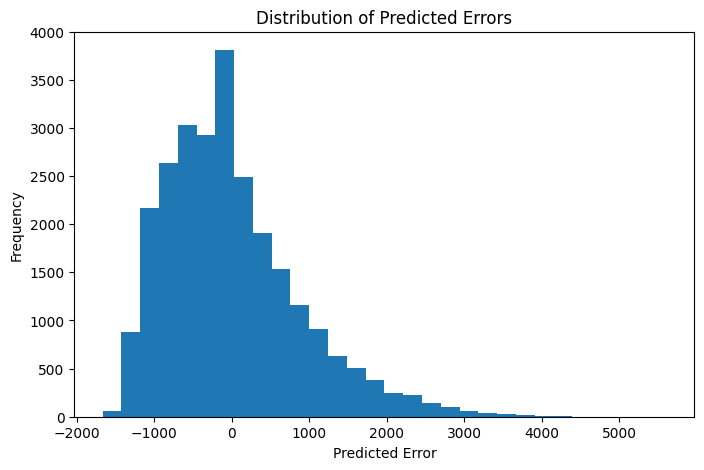

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.hist(error_df["Error"],bins=30)
plt.xlabel("Predicted Error")
plt.ylabel("Frequency")
plt.title("Distribution of Predicted Errors")
plt.show()

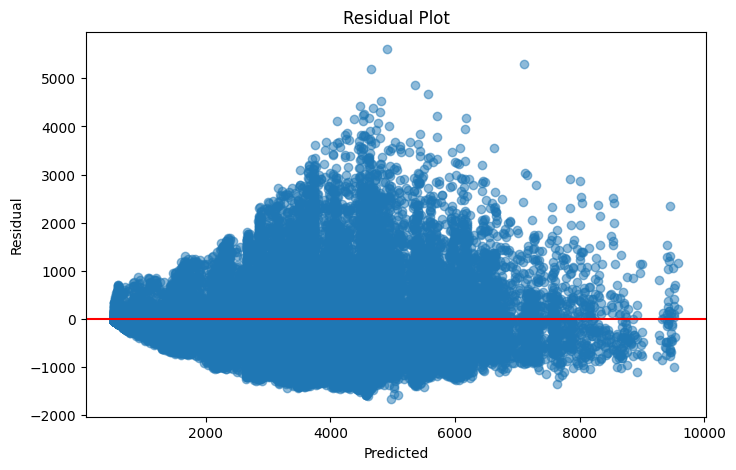

In [14]:
plt.figure(figsize=(8,5))
plt.scatter(
    error_df["Predicted"],
    error_df["Error"],
    alpha=0.5
)
plt.axhline(0,color="red")
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

In [15]:
error_df["Percentage Error"]=(error_df["Absolute Error"]/error_df["Actual"]*100)
error_df.head()

,Actual,Predicted,Error,Absolute Error,Percentage Error
32233,4164.52,5344.263885,-1179.743885,1179.743885,28.328448
28076,3231.62,3243.728068,-12.108068,12.108068,0.374675
14815,4078.42,4525.057814,-446.637814,446.637814,10.951246
6676,2098.82,2547.784518,-448.964518,448.964518,21.391283
5034,2188.02,2674.958461,-486.938461,486.938461,22.254754


In [16]:
from sklearn.metrics import r2_score

train_predictions = rf.predict(X_train)

test_predictions = rf.predict(X_test)

train_r2 = r2_score(y_train, train_predictions)
test_r2 = r2_score(y_test, test_predictions)

print("Training R²:", train_r2)
print("Testing R² :", test_r2)
print("Gap:", train_r2 - test_r2)

Training R²: 0.7977490704698962
Testing R² : 0.790597150346912
Gap: 0.007151920122984157


In [17]:
importance=pd.DataFrame({
     "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                Feature  Importance
0  monthly_expenses_usd    0.902907
1           savings_usd    0.094076
3          credit_score    0.001966
2       loan_amount_usd    0.001051


In [18]:
def recommend(row):

    recommendations = []

    #
    if row['monthly_expenses_usd'] > 0.8 * row['monthly_income_usd']:
        recommendations.append(
            "Reduce monthly expenses."
        )

    if row['savings_usd'] < 5000:
        recommendations.append(
            "Increase savings."
        )

    
    if row['loan_amount_usd'] > 100000:
        recommendations.append(
            "Focus on reducing outstanding loans."
        )

    if row['credit_score'] < 600:
        recommendations.append(
            "Improve credit score."
        )

    return " | ".join(recommendations)

In [19]:
df['Recommendation']=df.apply(
    recommend,
    axis=1
)
print(df['Recommendation'])

0                                    Improve credit score.
1        Focus on reducing outstanding loans. | Improve...
2                                                         
3                                    Improve credit score.
4         Reduce monthly expenses. | Improve credit score.
                               ...                        
32419    Focus on reducing outstanding loans. | Improve...
32420     Reduce monthly expenses. | Improve credit score.
32421                                Improve credit score.
32422     Reduce monthly expenses. | Improve credit score.
32423                                                     
Name: Recommendation, Length: 32424, dtype: str


In [20]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

df['Anomaly'] = iso.fit_predict(X_scaled)
print(df['Anomaly'].head())

0    1
1    1
2    1
3    1
4    1
Name: Anomaly, dtype: int64


In [21]:
anomalies=df[df['Anomaly']==-1]
print(anomalies.head())

    user_id  age  gender education_level employment_status    job_title  \
20   U00021   23    Male     High School           Student     Engineer   
84   U00085   35  Female        Bachelor           Student      Student   
99   U00100   29  Female     High School     Self-employed      Student   
101  U00102   46  Female        Bachelor     Self-employed   Unemployed   
161  U00162   21  Female          Master          Employed  Salesperson   

     monthly_income_usd  monthly_expenses_usd  savings_usd has_loan  ...  \
20              8237.77               7316.78     83622.72      Yes  ...   
84               500.00                186.16     44022.81      Yes  ...   
99              7693.61               2611.02    760095.88      Yes  ...   
101             5754.20               4350.50    309260.01      Yes  ...   
161             5568.07               3885.54      7925.20      Yes  ...   

    monthly_emi_usd  loan_interest_rate_pct  debt_to_income_ratio  \
20         13258.10    

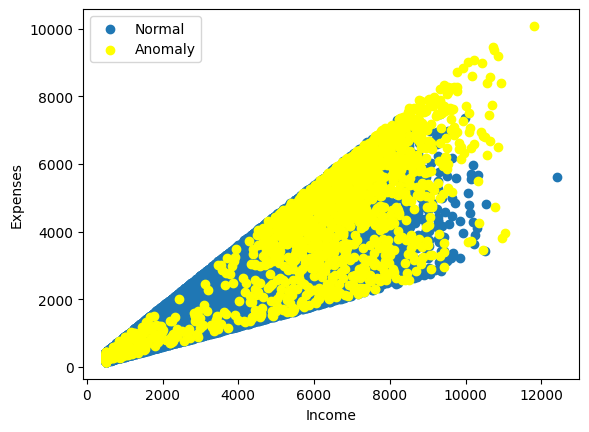

In [22]:
import matplotlib.pyplot as plt
plt.scatter(
    df[df['Anomaly']==1]['monthly_income_usd'],
    df[df['Anomaly']==1]['monthly_expenses_usd'],
    label='Normal'
)

plt.scatter(
    df[df['Anomaly']==-1]['monthly_income_usd'],
    df[df['Anomaly']==-1]['monthly_expenses_usd'],
    c='yellow',
    label='Anomaly'
)
plt.xlabel("Income")
plt.ylabel("Expenses")
plt.legend()
plt.show()